<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_11_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

###For this assignment heart_disease data description is given in heart_disease.xlsx. In order get the columns from the excel file, it is loading and reading. On analysing the data set in `The UCI Machine Learning Repository`it is found the data set has a column 'ca', which is  not mentioned in the excel description. so it has also been added in the description excel file. It is just to create the column name from the excel file itself, the excel is loading. Not necessary if we define the column with respect to the description.

In [ ]:
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [ ]:
description = pd.read_excel('/content/heart_disease.xlsx', header=None)

In [ ]:
description.head()

,0,1
0,age,Age in years
1,Gender,"Gender ; Male - 1, Female -0"
2,cp,Chest pain type
3,trestbps,Resting blood pressure
4,chol,cholesterol measure


In [ ]:
description.shape

(14, 2)

In [ ]:
description.values

array([['age', 'Age in years'],
       ['Gender', 'Gender ; Male - 1, Female -0'],
       ['cp', 'Chest pain type'],
       ['trestbps', 'Resting blood pressure'],
       ['chol', 'cholesterol measure'],
       ['fbs', '(fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)'],
       ['restecg',
        "ecg observation at resting condition,   -- Value 0: normal\n        -- Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)\n        -- Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria"],
       ['thalch', 'maximum heart rate achieved'],
       ['exang', 'exercise induced angina'],
       ['oldpeak', 'ST depression induced by exercise relative to rest'],
       ['slope', 'the slope of the peak exercise ST segment'],
       ['ca', 'coronary arteries number'],
       ['thal', 'Thal'],
       ['num',
        'target [0=no heart disease; 1,2,3,4 = stages of heart disease ]']],
      dtype=object)

In [ ]:
column_names = description.values[:, 0]
print(column_names)

['age' 'Gender' 'cp' 'trestbps' 'chol' 'fbs' 'restecg' 'thalch' 'exang'
 'oldpeak' 'slope' 'ca' 'thal' 'num']


##What each column means

age → Age of the person

Gender → 0 = female, 1 = male

cp → Chest pain type (0–3)

trestbps → Resting blood pressure

chol → Cholesterol level

fbs → Fasting blood sugar (>120 mg/dl)

restecg → ECG results

thalach → Max heart rate achieved

exang → Exercise-induced angina

oldpeak → ST depression

slope → Slope of ST segment

ca → Number of major vessels (0–3)

thal → Thalassemia type

target

0 → No heart disease

1, 2, 3, 4 - Stages of Heart disease present




##1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

###In this assignment, the dataset is not stored locally but is retrieved directly from an online source using a URL. Specifically, the Cleveland Heart Disease dataset is obtained from the UCI Machine Learning Repository, a well-known platform for machine learning datasets.

Accessing the dataset via URL improves reproducibility, as anyone can use the same link to obtain identical data. It also eliminates the need for manual downloading and ensures a more efficient and streamlined data loading process.

In [ ]:
#import pandas as pd (already done)

# URL of the Cleveland Heart Disease dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

#The data as such has no column names , so we are adding it
column_names = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]
# Load dataset
df = pd.read_csv(url, names=column_names)

# Show first rows
display(df.head())
print("\nDataset Shape:", df.shape)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Dataset Shape: (303, 14)



##2. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


##Data cleaning
df.describe shows that 'ca' and 'thal' are object data types. it seems the values are numerical. Let us cheque which values are objects.


In [ ]:
# cheque unique values in 'ca', 'thal'
print(df['ca'].unique())
print(df['thal'].unique())

['0.0' '3.0' '2.0' '1.0' '?']
['6.0' '3.0' '7.0' '?']


In [ ]:
#print number of each unique value in 'ca' and 'thal'
print(df['ca'].value_counts())
print(df['thal'].value_counts())

ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64
thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64


in 'ca' the value '?' exists 4 times

in 'thal' the value '?' exists 2 times.

let us replace it with null value

In [ ]:
#replace '?' with Nan in 'ca' and 'thal'
import numpy as np
df['ca'] = df['ca'].replace('?', np.nan)
df['thal'] = df['thal'].replace('?', np.nan)

In [ ]:
# cheque unique values in 'ca', 'thal'
print(df['ca'].unique())
print(df['thal'].unique())

['0.0' '3.0' '2.0' '1.0' nan]
['6.0' '3.0' '7.0' nan]


Variables where 0(zero) is also missing values.

`trestbps`, `chol`, `thalch`

These represent vital physiological measurements, and a value of 0 is incompatible with life, so it indicates a recording error or missing entry.
Replace 0 with NaN now and then with median (these are often skewed and may contain outliers)

`thal`

This is a categorical variable with defined classes (e.g., 3, 6, 7), and 0 is not a valid category.
Replace 0 with Nan and then mode (most frequent category)

`age`

Age = 0 is unrealistic for a heart disease dataset focused on adults, so it likely represents missing data.
Replace 0 with NaN and then with median (age distributions can be slightly skewed)

In [ ]:
#replace 0's in 'trestbps','chol','thalach','thal','age' with NaN
df[['trestbps','chol','thalach','thal','age']] = \
df[['trestbps','chol','thalach','thal','age']].replace(0, np.nan)

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
#replace null values in 'ca' and 'thal' with mode
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal']=df['thal'].fillna(df['thal'].mode()[0])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


###`ca`, `thal` - still objects

'ca' and 'thal' are stored as object types, even though they represent numeric values. This happens because these columns originally contained mixed entries such as '0.0', '3.0', '?', or NaN. Even after replacing '?' with NaN and imputing missing values (e.g., using the mode), Pandas may still treat the columns as object type due to the presence of string representations of numbers or mixed data types.

To ensure proper conversion, it is safer to first cast these columns to float. This step standardizes all values into numeric form (e.g., 0.0, 1.0). Once the data is consistently in float format, converting to int using astype(int) will correctly yield integer values (e.g., 0, 1).

In [ ]:
df['ca'] = df['ca'].astype(float).astype(int)
df['thal'] = df['thal'].astype(float).astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 33.3 KB


###Summary Statistics

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In summary, trestbps, chol, and oldpeak appear to have values that could be considered extreme outliers, possibly indicating very high or unusual measurements in some individuals. Further investigation using visualizations like box plots would confirm these visually and allow for a deeper understanding.

###EDA - Plots, Correlation.



First , finding which are categorical columns. we are checking which columns have less than 10 unique values and see the values.

In [ ]:
for col in df.columns:
  if df[col].nunique() < 10:
    print(f"\nUnique values for column: {col} - {df[col].nunique()}")
    #print(f"The unique values are:{df[col].unique()}")
    print(f"The unique values are:{', '.join(map(str, df[col].unique()))}")
    print("-" * 30) # Separator for readability


Unique values for column: sex - 2
The unique values are:1.0, 0.0
------------------------------

Unique values for column: cp - 4
The unique values are:1.0, 4.0, 3.0, 2.0
------------------------------

Unique values for column: fbs - 2
The unique values are:1.0, 0.0
------------------------------

Unique values for column: restecg - 3
The unique values are:2.0, 0.0, 1.0
------------------------------

Unique values for column: exang - 2
The unique values are:0.0, 1.0
------------------------------

Unique values for column: slope - 3
The unique values are:3.0, 2.0, 1.0
------------------------------

Unique values for column: ca - 4
The unique values are:0, 3, 2, 1
------------------------------

Unique values for column: thal - 3
The unique values are:6, 3, 7
------------------------------

Unique values for column: target - 5
The unique values are:0, 2, 1, 3, 4
------------------------------


In [ ]:
#columns with nunique()<=5 and columns with nunique > 5
cols_less_than_5 = []
cols_more_than_5 = []
for col in df.columns:
  if df[col].nunique() <=5:
    cols_less_than_5.append(col)
  else:
    cols_more_than_5.append(col)
print(f"Columns with nunique() <= 5: {cols_less_than_5}")
print(f"Columns with nunique() > 5: {cols_more_than_5}")

Columns with nunique() <= 5: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
Columns with nunique() > 5: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


Columns with nunique() <= 5:

 ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

Columns with nunique() > 5:

 ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [ ]:
# Checking number of unique values in 'cols_more_than5'
for col in cols_more_than_5:
  print(f"Unique values for column: {col} - {df[col].nunique()}")

Unique values for column: age - 41
Unique values for column: trestbps - 50
Unique values for column: chol - 152
Unique values for column: thalach - 91
Unique values for column: oldpeak - 40


###In the data set

`cols_more_than5` are continuous numerical columns

`cols_less_than_5` are categorical numeric columns



##Next - EDA , Outlayers, Encoding, Scaling

###1.Histogram of features -continuous columns

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

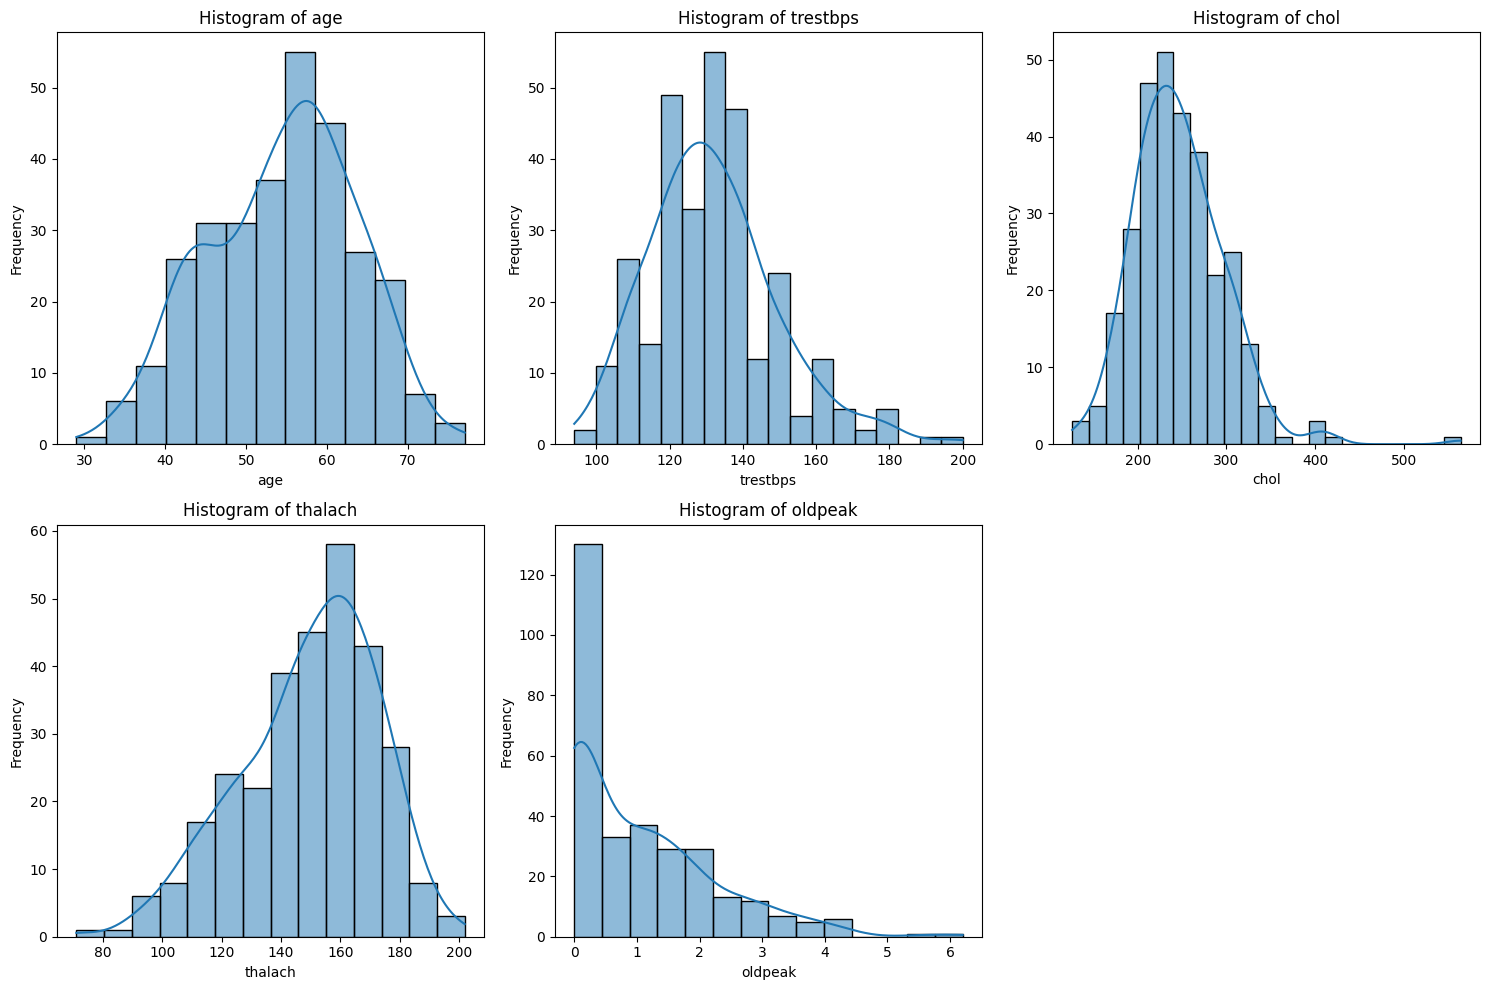

In [ ]:

continuous_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))

for i, col in enumerate(continuous_columns):
    plt.subplot(2, 3, i + 1)
    sns.histplot(x=df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Here are the histograms for the continuous numerical columns in the dataset. These plots provide a visual representation of the distribution of each variable:

*   **`age`**: The distribution appears somewhat normal, possibly slightly skewed to the right.
*   **`trestbps` (resting blood pressure)**: Shows a distribution centered around 120-140 mmHg, with a tail extending to higher values.
*   **`chol` (cholesterol measure)**: The distribution is generally skewed to the right, indicating more individuals with lower cholesterol levels and a fewer with very high levels.
*   **`thalach` (maximum heart rate achieved)**: This distribution seems relatively normal or slightly skewed left, with most values falling between 120 and 180 bpm.
*   **`oldpeak` (ST depression induced by exercise)**: Heavily skewed to the right, with many values at or near zero and a few higher values.

###2.count plots for the categorical columns:

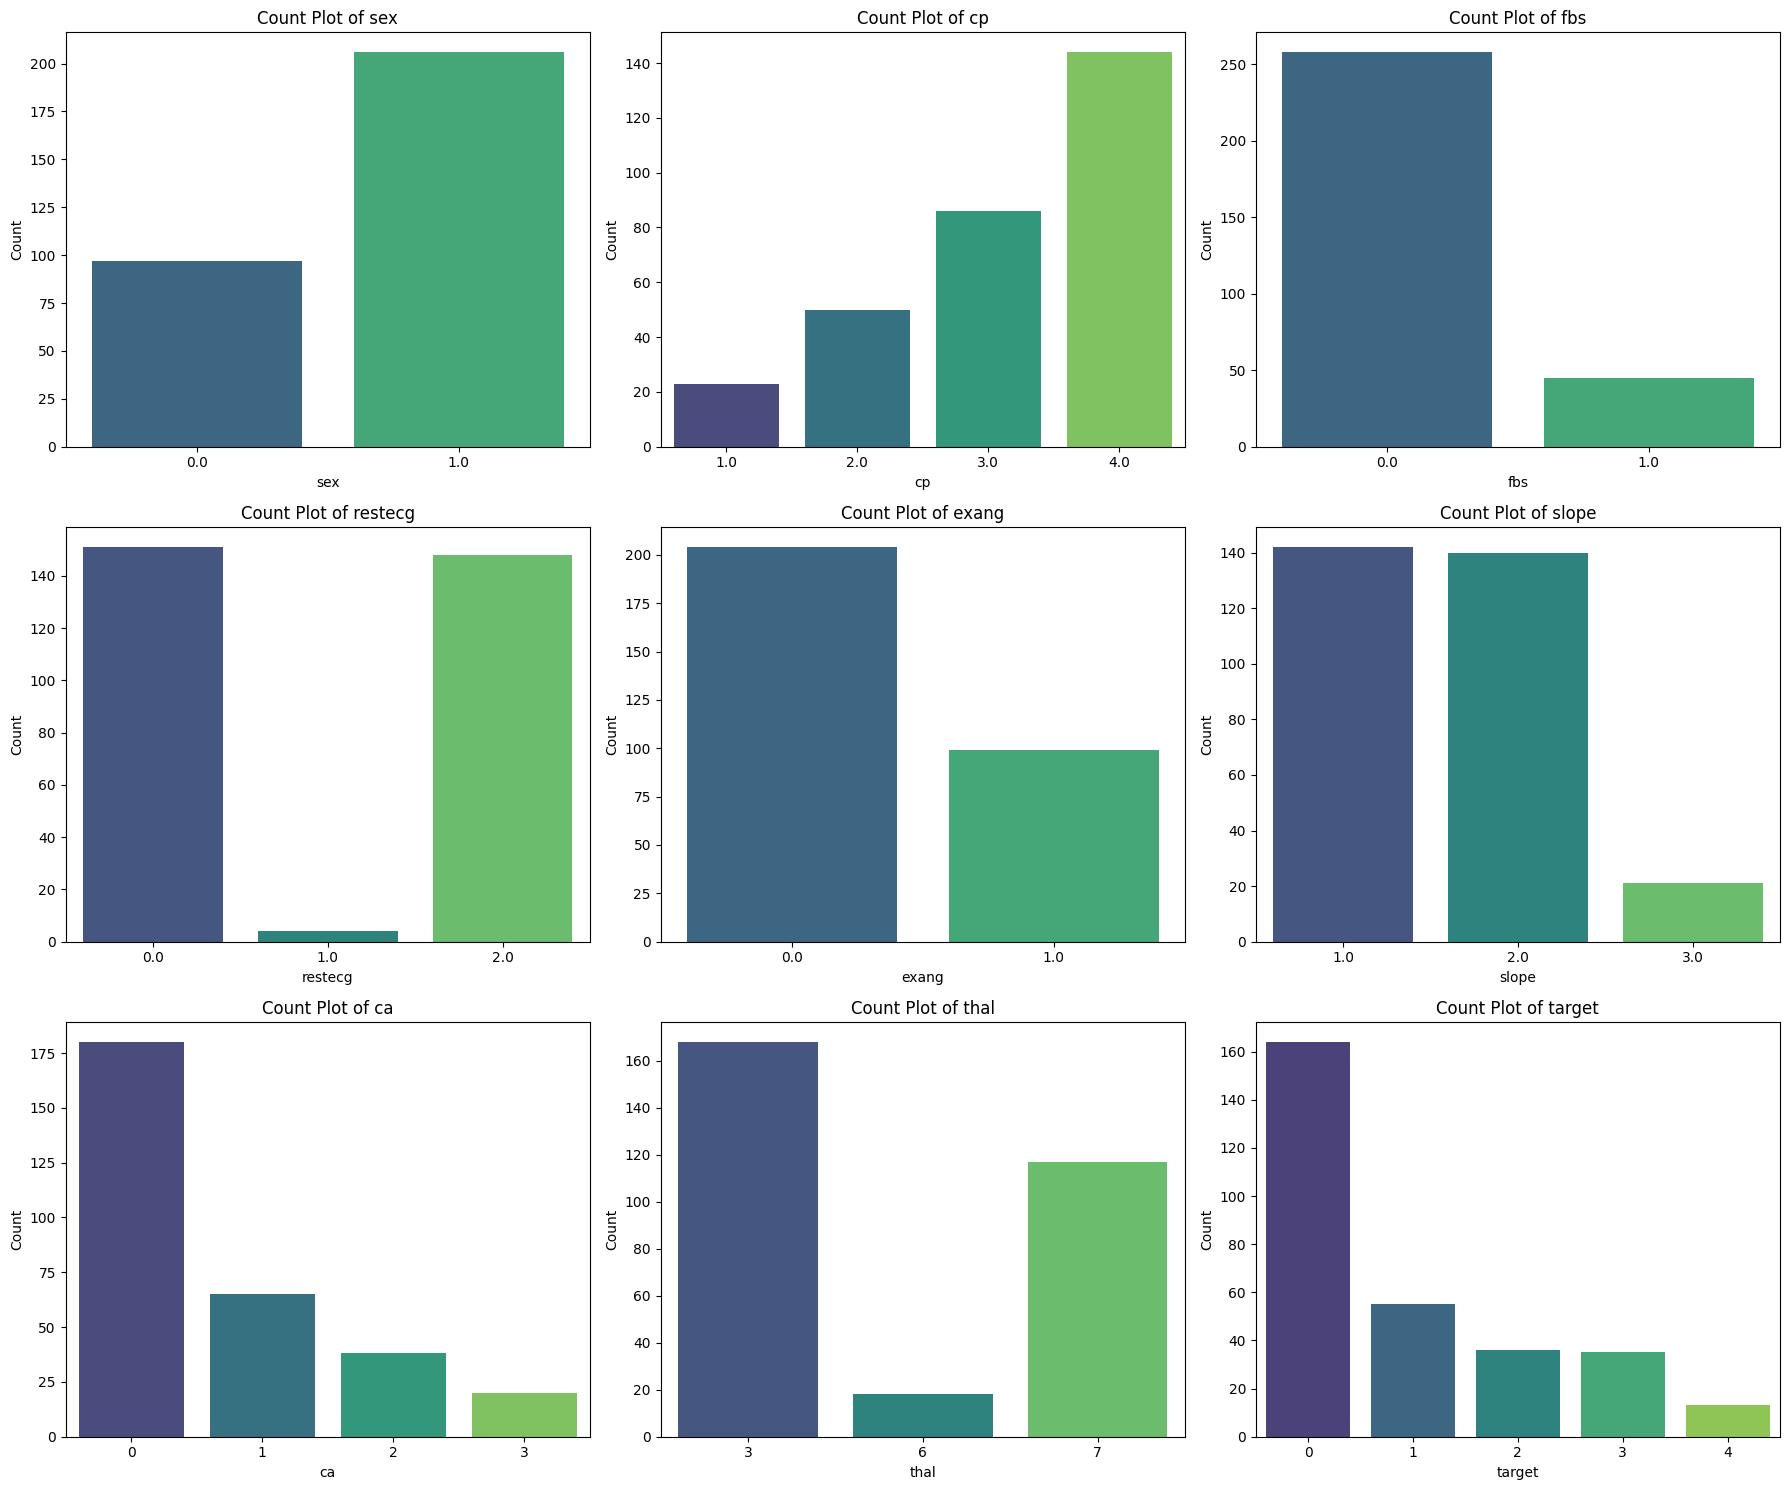

In [ ]:
#count plots
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_columns):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

These count plots illustrate the distribution of values within each categorical column:

*   **`sex`**: Shows the distribution of male (1.0) and female (0.0) individuals in the dataset.
*   **`cp` (chest pain type)**: Displays the frequency of different chest pain types.
*   **`fbs` (fasting blood sugar)**: Shows the counts for blood sugar levels above (1.0) or below (0.0) 120 mg/dl.
*   **`restecg` (resting electrocardiographic results)**: Visualizes the distribution across different ECG result categories.
*   **`exang` (exercise-induced angina)**: Indicates whether exercise-induced angina is present (1.0) or absent (0.0).
*   **`slope` (the slope of the peak exercise ST segment)**: Shows the distribution of different ST segment slopes.
*   **`ca` (number of major vessels)**: Represents the counts for the number of major vessels colored by fluoroscopy.
*   **`thal` (Thalassemia)**: Displays the distribution of Thalassemia types.
*   **`target` (diagnosis of heart disease)**: Shows the distribution of heart disease presence (0) or absence (1), after the encoding step.

###3.Box Plots

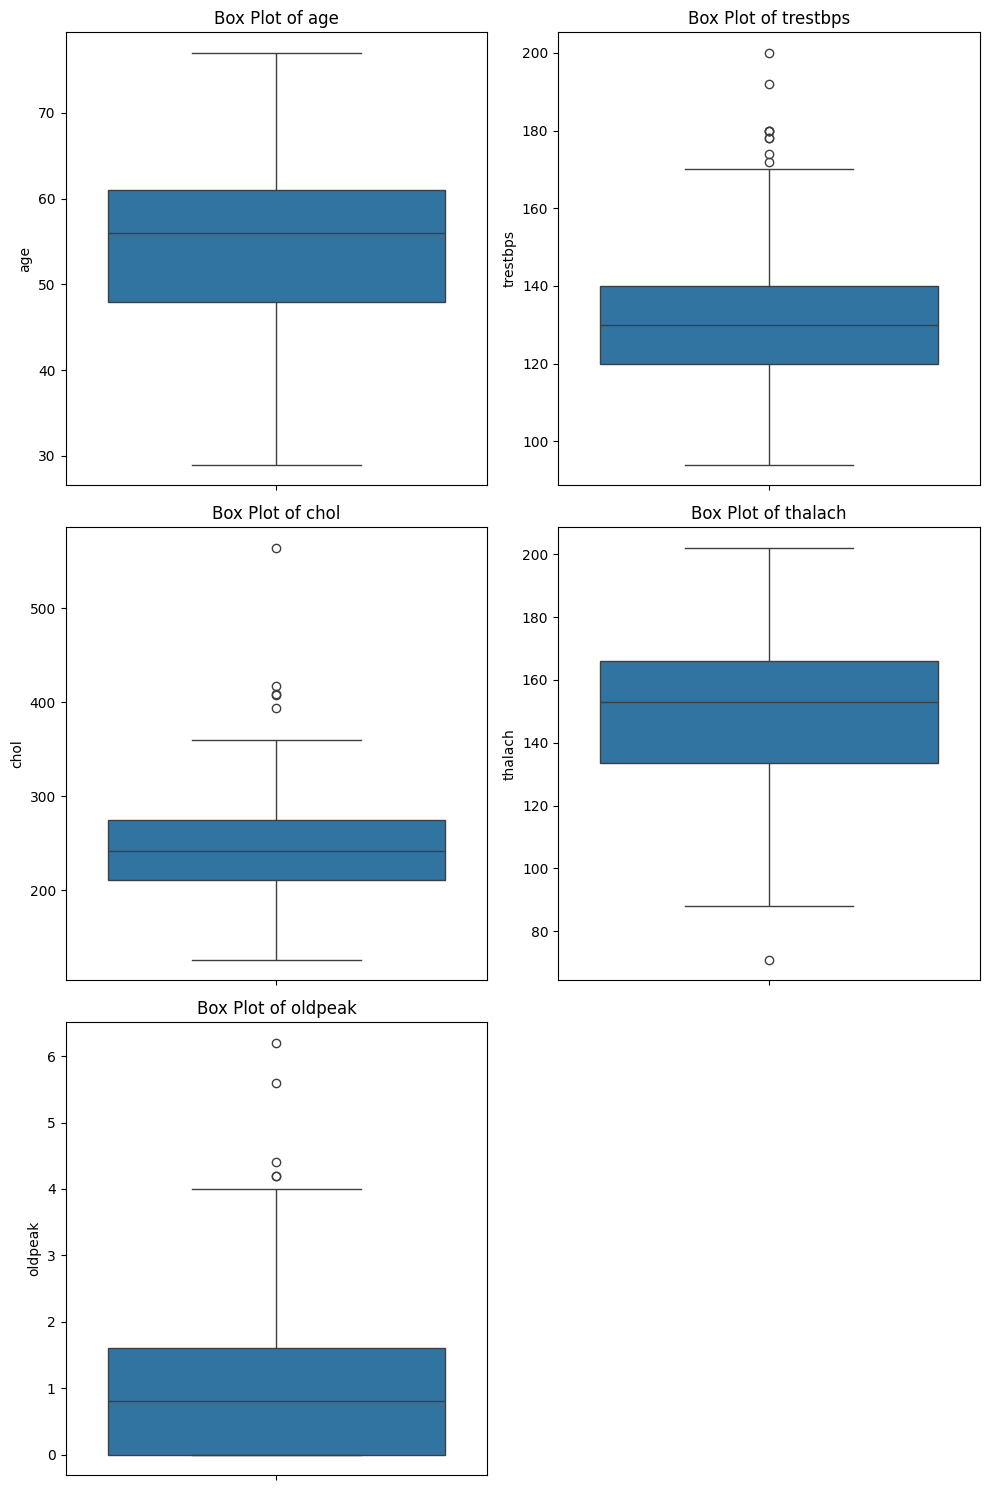

In [ ]:
#Box plots

continuous_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(10, 15))

for i, col in enumerate(continuous_columns):
    plt.subplot(3, 2, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


The box plots show the distribution for each continuous variable. Key observations:
- **`age`**: The distribution is relatively symmetrical, with no extreme outliers.
- **`trestbps` (resting blood pressure)**: There are a few values that extend significantly above the upper whisker, indicating potential high outliers.
- **`chol` (cholesterol measure)**: This column shows several points above the upper whisker, suggesting high cholesterol outliers.
- **`thalach` (maximum heart rate achieved)**: The distribution appears somewhat normal, with some potential low outliers.
- **`oldpeak` (ST depression induced by exercise)**: This variable has a number of values extending far above the upper whisker, indicating significant outliers for ST depression.

These visualizations confirm the presence of outliers in `trestbps`, `chol`, `thalach`, and `oldpeak`, as suggested by the `df.describe()` output. These outliers may warrant further investigation or special handling during modeling.

Models like Decision Tree are:

Non-parametric

Based on splits, not distances

Naturally robust to outliers

This means:

Outliers usually do NOT harm decision trees the way they harm models like linear regression or KNN. So, we will train the  model without outlier treatment and see performance.

Correlation

Heat map

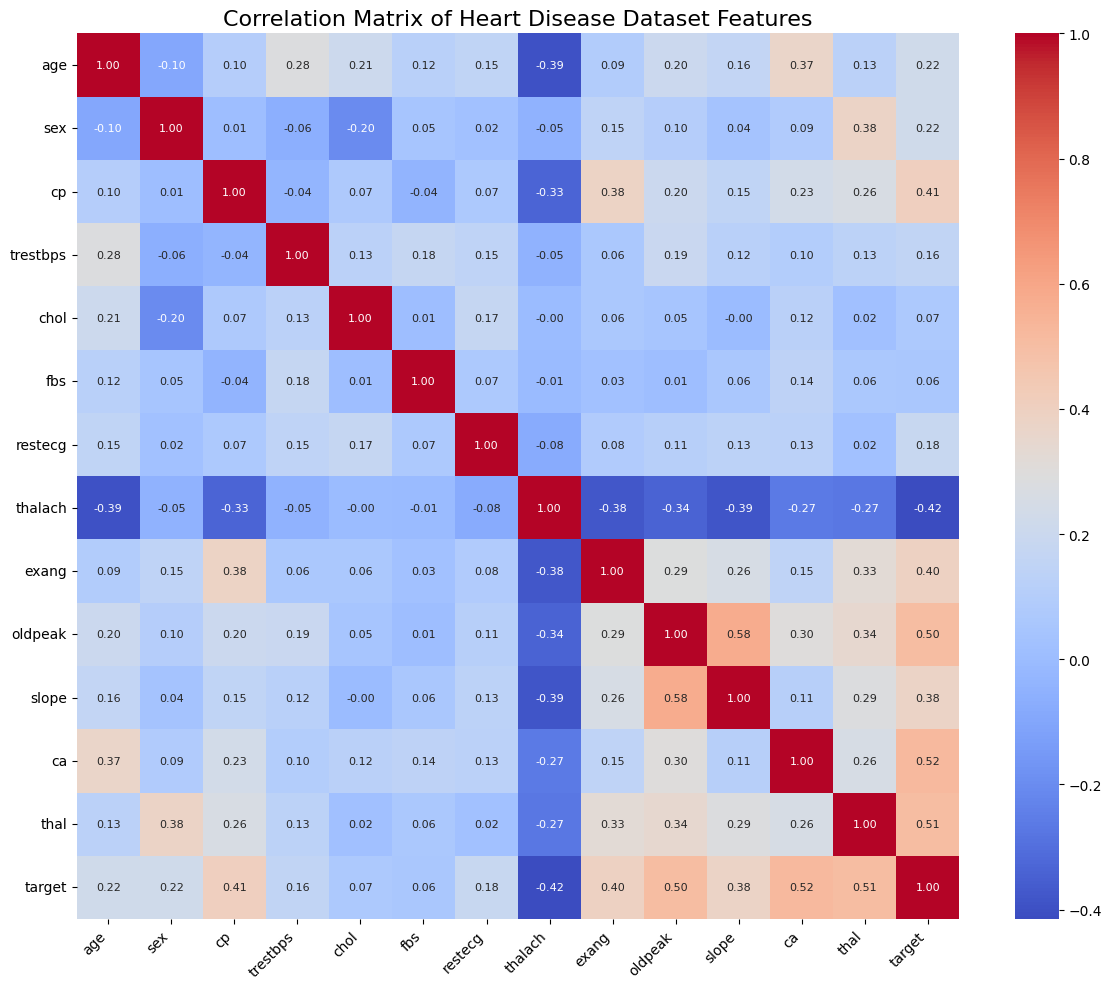

In [ ]:
#heat map of the features
plt.figure(figsize=(12, 10)) # Increase figure size for better readability
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8}) # Add font size to annotations
plt.title('Correlation Matrix of Heart Disease Dataset Features', fontsize=16) # Add a title
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.yticks(rotation=0)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

From the heatmap, the 'target' variable (which indicates the presence of heart disease) shows significant correlations with several features:

Strong positive (e.g. > 0.4) → useful predictor

Strong negative (e.g. < -0.4) → also useful

Near 0 → weak relationship

Strong Positive Correlations:

cp (chest pain type), exang (exercise induced angina), oldpeak (ST depression induced by exercise), ca (number of major vessels colored by flourosopy), and thal (Thalassemia type) show strong positive correlations with the target. This suggests that as values in these features increase, the likelihood of heart disease also tends to increase.

Moderate Positive Correlations:

 sex also shows a moderate positive correlation.

Moderate Negative Correlation:

thalach (maximum heart rate achieved) shows a moderate negative correlation. This implies that higher maximum heart rates are associated with a lower likelihood of heart disease.

Weaker Correlations: Other features like age, trestbps, chol, fbs, and restecg show weaker correlations with the 'target' variable.

Some features show inter-correlation; however, since decision tree models are not significantly affected by multicollinearity, all features are retained for model training.



###3 Feature Engineering - Encoding , Scaling



###Encoding

Binary features → No encoding needed

sex (0,1)

fbs (0,1)

exang (0,1)

Already numeric and meaningful.
Use as-is
***********************************

Ordinal features →  Keep as numeric

ca (0–3 → number of vessels)

slope (1–3 → ordered categories)

 Have natural order.
 No encoding required
**********************************

Nominal features → One-Hot Encoding

cp (types of chest pain)

restecg (ECG types)

thal (test result categories)

No inherent order




In [ ]:
#One_hot_encoding.
df = pd.get_dummies(data=df, columns=['cp','restecg','thal'], drop_first=True)

Categorical variables were analyzed based on their nature. Binary and ordinal variables were retained in their original encoded form. Nominal variables such as cp, thal, and restecg were transformed using one-hot encoding to avoid introducing artificial ordinal relationships. This ensures that the decision tree model interprets categorical distinctions correctly.

In [ ]:
display(df.head())
print("\nDataset Shape:", df.shape)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,thal_6,thal_7
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,3.0,0,0,False,False,False,False,True,True,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,2.0,3,2,False,False,True,False,True,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,2,1,False,False,True,False,True,False,True
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,3.0,0,0,False,True,False,False,False,False,False
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,1.0,0,0,True,False,False,False,True,False,False



Dataset Shape: (303, 18)


###Target variable

The target variable was converted into a binary outcome where 0 represents absence of heart disease and values 1–4 indicate presence of heart disease. This simplifies the problem into a classification task and improves model interpretability.

In [ ]:
display(df['target'].value_counts())

,count
target,
0,164
1,55
2,36
3,35
4,13


In [ ]:
#Encoding(Converting)target.

import numpy as np

df['target'] = np.where(df['target'] == 0, 0, 1)

In [ ]:
display(df['target'].value_counts())

,count
target,
0,164
1,139


##Scaling

Since decision tree models are scale-invariant and rely on feature splitting rather than distance calculations, feature scaling was not applied. Both categorical and continuous variables were used in their original form without normalization or standardization.

##4. Decision Tree Classification
🔹 Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (242, 17)
Testing shape: (61, 17)


##Train Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

##Predictions

In [ ]:
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

##. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8032786885245902
Precision: 0.8333333333333334
Recall: 0.78125
F1 Score: 0.8064516129032258
ROC-AUC: 0.8044181034482758

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        29
           1       0.83      0.78      0.81        32

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



In [ ]:
25/(25+7)

0.78125

##Confusion Matrix

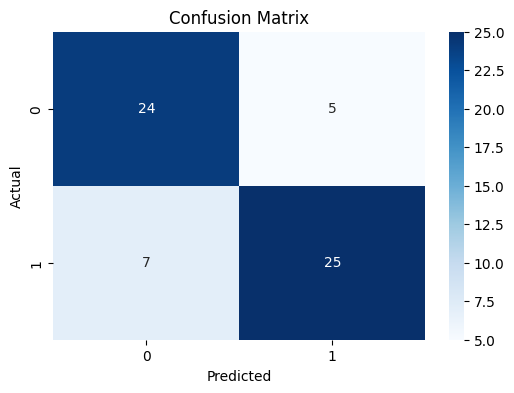

In [ ]:
from sklearn.metrics import confusion_matrix
#import seaborn as sns
#import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
#cm = confusion_matrix(y_pred, y_test)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

###Explanation of Metrics

Accuracy → overall correctness

Precision → how many predicted
positives are correct

Recall → how many actual positives captured

F1-score → balance between precision & recall

ROC-AUC → model’s ability to separate classes

##5. Hyperparameter Tuning
🔹 Using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}


The GridSearchCV process identified that a relatively shallow Decision Tree (max_depth=3) using the 'entropy' criterion for splitting is the best configuration for predicting heart disease with this dataset. This tuned model is then used for making final predictions and evaluating its performance, as seen in subsequent cells.

In [ ]:
dir(grid)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_check_refit_for_multimetric',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_format_results',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_routed_params_for_fit',
 '_get_scorers',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_run_sea

In [ ]:
grid.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

###6.Model Evaluation and Analysis:

Analyse the performance of the Decision Tree model using the evaluation metrics obtained.

In [ ]:
#find best model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:,1]

In [ ]:
#print tuned metrics
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned F1:", f1_score(y_test, y_pred_best))
print("Tuned ROC-AUC:", round(roc_auc_score(y_test, y_prob_best),3))

Tuned Accuracy: 0.8360655737704918
Tuned F1: 0.84375
Tuned ROC-AUC: 0.895


The tuned Decision Tree model demonstrates strong predictive performance, achieving an accuracy of approximately 83.6%, which indicates that it correctly classifies the presence or absence of heart disease in most cases. The F1-score of around 84.4% reflects a well-balanced trade-off between precision and recall, suggesting the model is effective at identifying true positive(TP) cases while keeping both false positives(FP) and false negatives(FN)under control. Additionally, the ROC-AUC score of 89.5% highlights the model’s excellent discriminative ability, meaning it can reliably distinguish between patients with and without heart disease.

Overall, the Decision Tree model performs well in predicting heart disease, with noticeable improvements after hyperparameter tuning. Key features such as chest pain type (cp), number of major vessels (ca), and thalassemia (thal) contribute significantly to the model’s decisions. Moreover, the inherent interpretability of Decision Trees—through clear and transparent decision rules—makes this model particularly valuable for medical decision support, where explainability is crucial.


###Visualize the decision tree structure to understand the rules learned by the model and identify important features

Top 10 Feature Importances:
cp_4.0      0.393635
ca          0.188595
thal_7      0.113659
age         0.109030
sex         0.075276
chol        0.071237
oldpeak     0.048569
fbs         0.000000
trestbps    0.000000
slope       0.000000
dtype: float64


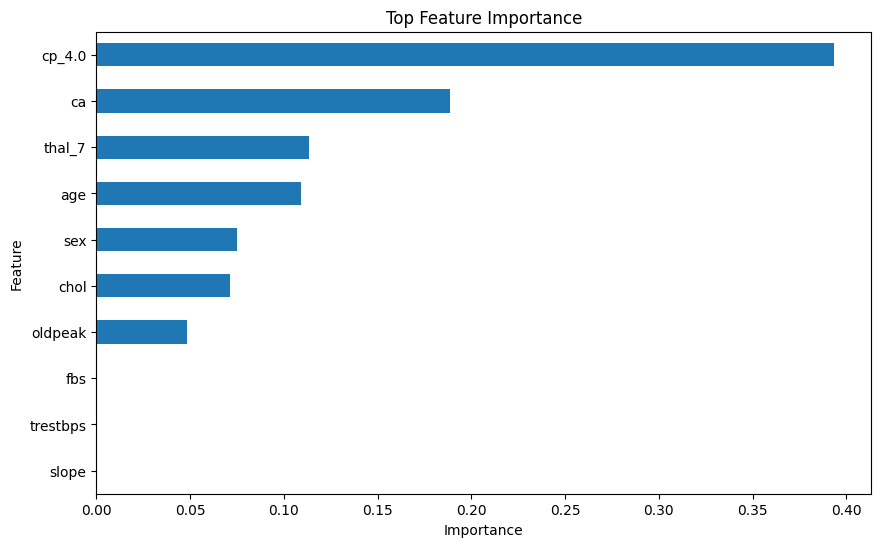

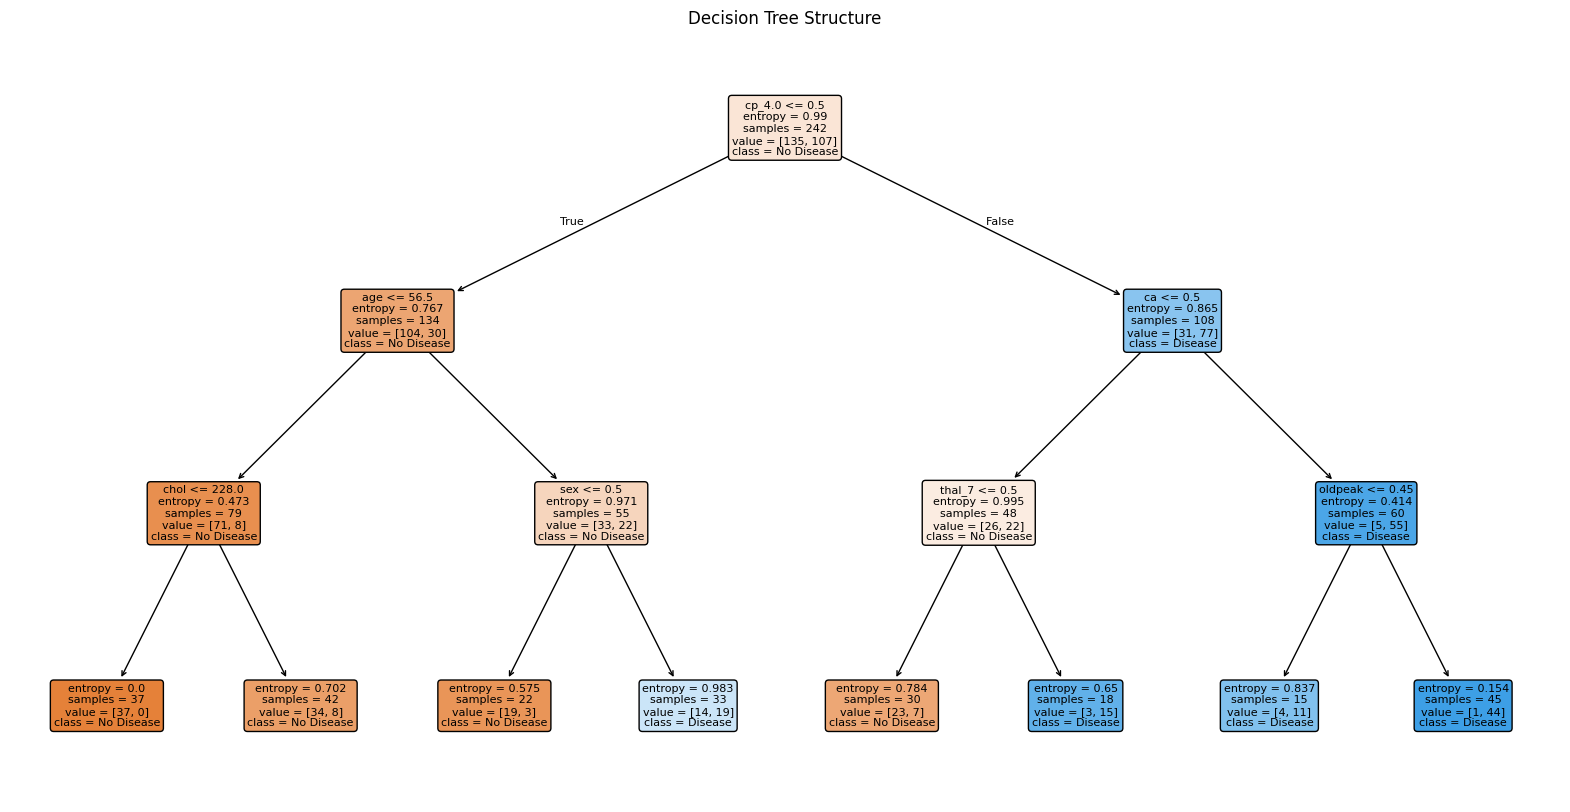

In [ ]:
#import pandas as pd
#import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize Feature Importance
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Feature Importances:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind='barh')#horizontal bar plot
plt.title("Top Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis() # To show the most important feature at the top
plt.show()

# Visualize the Decision Tree Structure
plt.figure(figsize=(20,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure")
plt.show()

###Overall Insight:


The most important features for this heart disease prediction model are cp_4.0 (Chest Pain Type 4), ca (Number of Major Vessels), and thal_7 (Thalassemia Type 7), followed by age and sex. The decision tree structure then uses these features to make predictions:

Root Node: The tree starts by splitting on cp_4.0. If cp_4.0 is 0 (meaning no chest pain type 4), it typically leads down a path with a lower probability of heart disease. If cp_4.0 is 1, it generally indicates a higher likelihood of heart disease.

Next Nodes: Following the cp_4.0 split, the tree branches further using other significant features like ca and thal_7. For example, within the 'no chest pain type 4' group, the model might then check the number of major vessels (ca) or the specific thalassemia type (thal_7) to refine its prediction, leading down to age and sex for further differentiation in later nodes. Each node represents an 'if-then' rule, guiding the classification process until a final prediction is reached.



##Interview Questions

###1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Decision trees have hyperparameters that control how the tree grows. These directly affect whether the model is too simple (underfitting) or too complex (overfitting).

Important Hyperparameters

1.max_depth

Limits how deep the tree can grow.

 Smaller depth → simpler model (may miss patterns)

 Larger depth → complex model (may overfit)

2.min_samples_split

Minimum number of data points needed to split a node.
Higher value → fewer splits → simpler tree

3.min_samples_leaf

Minimum number of data points in a leaf node.
Prevents very small leaves → reduces overfitting

4.criterion

Method used to decide the best split (Gini or Entropy).
Helps the model choose better splits

5.max_features

Number of features considered at each split.
 Fewer features → more randomness → better generalization


In summary,Hyperparameters help control the complexity of a decision tree.
By adjusting them, we can avoid overfitting and build a model that generalizes well to new data.

###2. What is the difference between the Label encoding and One-hot encoding?

Label Encoding vs One-Hot Encoding

Both techniques are used to convert categorical data into numerical form so that machine learning models can understand it.

🔹 Label Encoding
Converts each category into a unique integer

Example:

Red → 0

Blue → 1

Green → 2

Advantage:
Simple and memory efficient

Problem:
Introduces a false order (e.g., 2 > 1 > 0), even when no real ranking exists
Can mislead models into thinking one category is “greater” than another

One-Hot Encoding

Creates separate binary columns for each category
Example:

Red → [1, 0, 0]

Blue → [0, 1, 0]

Green → [0, 0, 1]

Advantage:
No false ordering → treats all categories equally

Limitation:
Increases the number of columns (can be inefficient with many categories)

 Key Difference:

Label Encoding: Assigns numbers → may create unwanted order

One-Hot Encoding: Uses binary vectors → no order assumption


In short,Label encoding is compact but can introduce misleading relationships, while one-hot encoding avoids this issue by representing categories independently, making it more suitable for nominal (unordered) data.

##END